In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TASK_DIR = Path.cwd().parent
INPUT_DIR = TASK_DIR / "input"
OUTPUT_DIR = TASK_DIR / "output"

AR1_NAME = "AR(1)-GRW-S"
ARW4_NAME = "ARW4"
MODEL_TAG = "stagewise_ar1_grw_arw4"
Y = 20
YEARS = np.arange(Y + 1)

palette = ["#0072B2","#D55E00","#006D4E","#6A3D9A","#9E2F50"]
EMP_COLOR, AR1_COLOR, ARW4_COLOR = palette[3], palette[1], palette[0]
model_specs = [("Empirical",EMP_COLOR,"-"),(AR1_NAME,AR1_COLOR,"--"),(ARW4_NAME,ARW4_COLOR,"-.")]
trajectory_stage_spans = [(0,0,"0.70"),(1,4,"0.78"),(5,7,"0.86"),(8,20,"0.93")]
transition_stage_spans = [(1,4,"0.78"),(5,7,"0.86"),(8,20,"0.93")]
stage_order = ["years_1_4","years_5_7","years_8_20"]
stage_titles = {"years_1_4": "Years 1-4","years_5_7": "Years 5-7","years_8_20": "Years 8-20"}

OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"figure.facecolor": "white","axes.facecolor": "white","savefig.facecolor": "white","font.size": 10,"axes.titlesize": 11,"axes.labelsize": 10,"legend.fontsize": 9})

In [2]:
def combine(name):
    ar1 = pd.read_csv(INPUT_DIR / name); arw4 = pd.read_csv(INPUT_DIR / f"arw4_{name}")
    emp = ar1.loc[ar1.source.eq("empirical")].assign(model="Empirical")
    ar1 = ar1.loc[ar1.source.eq("simulated")].assign(model=AR1_NAME)
    arw4 = arw4.loc[arw4.source.eq("simulated")].assign(model=ARW4_NAME)
    return pd.concat([emp,ar1,arw4],ignore_index=True)

def save_figure(fig, stem):
    fig.savefig(OUTPUT_DIR / f"{MODEL_TAG}_{stem}.png",dpi=300,bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{MODEL_TAG}_{stem}.pdf",bbox_inches="tight")
    plt.show(); plt.close(fig)

def shade_stages(ax, spans):
    for start,end,shade in spans: ax.axvspan(start - .5,end + .5,facecolor=shade,alpha=.65,zorder=0)

def finish(ax, xlabel, ylabel, title=None):
    if title: ax.set_title(title)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.grid(True,alpha=.3)

def lines(ax, df, x, y):
    for model,color,ls in model_specs:
        d = df.loc[df.model.eq(model)].sort_values(x)
        ax.plot(d[x],d[y],color=color,linestyle=ls,linewidth=2,label=model)

def laplace_pdf(x, mu, alpha): return np.exp(-np.abs(x - mu) / alpha) / (2 * alpha)

def ecdf(x):
    x = np.sort(np.asarray(x)); return x, np.arange(1,len(x) + 1) / len(x)

In [3]:
canonical = combine("canonical_trajectory_stats.csv")
yearwise = combine("yearwise_productivity_stats.csv")
log_delta = combine("yearwise_log_delta_stats.csv")
laplace = combine("stage_raw_increment_laplace.csv")
laplace_values = combine("stage_raw_increment_values.csv")
qq = combine("lognormal_qq_coordinates.csv")
rank_corr = combine("rank_correlations.csv")
aggregate = combine("aggregate_productivity_values.csv")
wasserstein_ar1 = pd.read_csv(INPUT_DIR / "wasserstein_by_year.csv")
wasserstein_arw4 = pd.read_csv(INPUT_DIR / "arw4_wasserstein_by_year.csv")
ar1_params = pd.read_csv(INPUT_DIR / "stage_grw_params.csv")
arw4_params = pd.read_csv(INPUT_DIR / "arw4_params.csv")

print(f"Models: Empirical, {AR1_NAME}, {ARW4_NAME}")

Models: Empirical, AR(1)-GRW-S, ARW4


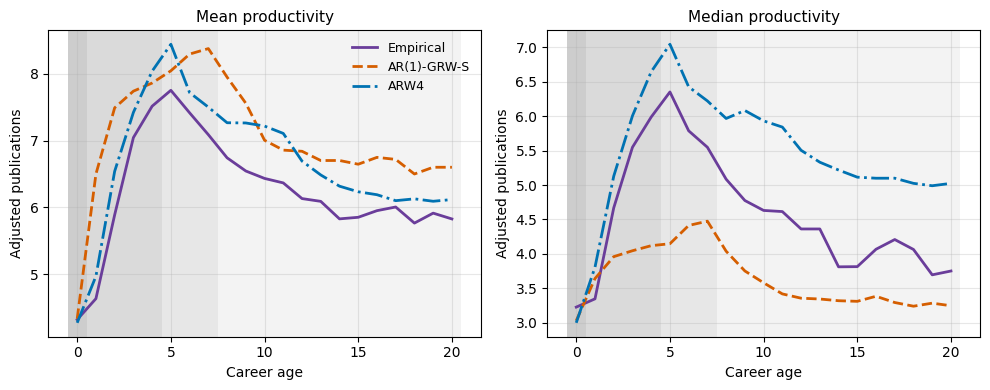

In [4]:
fig, ax = plt.subplots(1,2,figsize=(10,4),sharex=True)
for a,y,title in zip(ax,["mean","median"],["Mean productivity","Median productivity"]):
    shade_stages(a,trajectory_stage_spans); lines(a,canonical,"career_age",y); finish(a,"Career age","Adjusted publications",title)
ax[0].legend(frameon=False)
fig.tight_layout(); save_figure(fig,"prodSpaceMeanVsMedian")

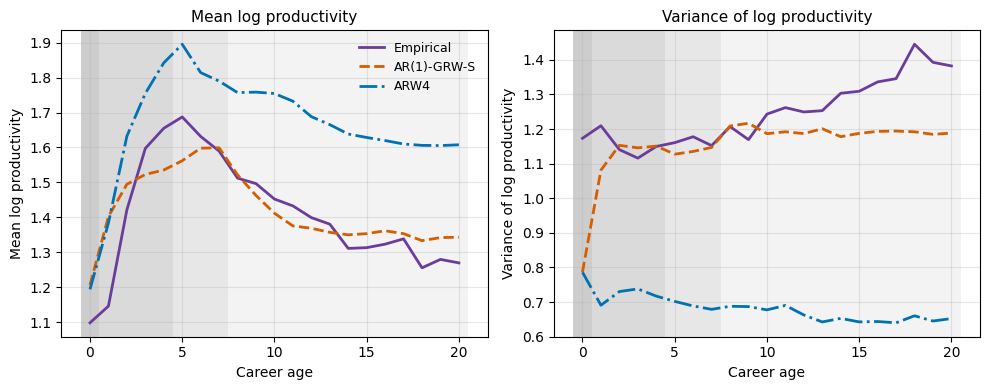

In [5]:
fig, ax = plt.subplots(1,2,figsize=(10,4),sharex=True)
for a,y,title in zip(ax,["mean_log_prod","var_log_prod"],["Mean log productivity","Variance of log productivity"]):
    shade_stages(a,trajectory_stage_spans); lines(a,yearwise,"career_age",y); finish(a,"Career age",title,title)
ax[0].legend(frameon=False)
fig.tight_layout(); save_figure(fig,"logCompare")

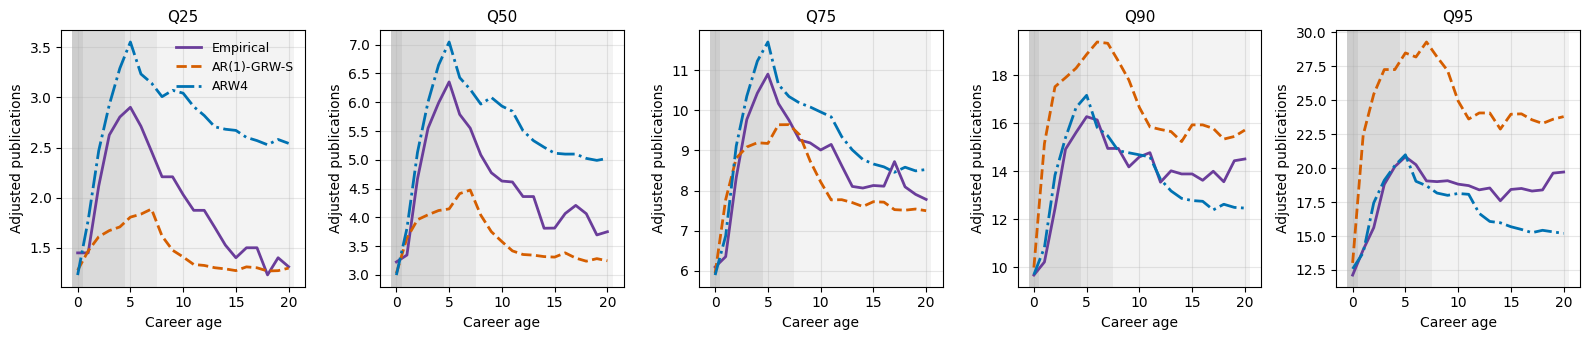

In [6]:
quantiles = ["q25_prod","q50_prod","q75_prod","q90_prod","q95_prod"]
fig, ax = plt.subplots(1,5,figsize=(16,3.5),sharex=True)
for a,y,q in zip(ax,quantiles,[25,50,75,90,95]):
    shade_stages(a,trajectory_stage_spans); lines(a,yearwise,"career_age",y); finish(a,"Career age","Adjusted publications",f"Q{q}")
ax[0].legend(frameon=False)
fig.tight_layout(); save_figure(fig,"quantiles")

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(13,4),sharex=True)
for a,y,title in zip(ax,["mean_log_delta","median_log_delta","var_log_delta"],["Mean","Median","Variance"]):
    shade_stages(a,transition_stage_spans); lines(a,log_delta,"destination_year",y); finish(a,"Destination year",title,f"{title} log increment")
ax[0].legend(frameon=False)
fig.tight_layout(); save_figure(fig,"logDeltaMoments")

In [ ]:
ar1_beta = pd.concat([pd.DataFrame({"career_age": np.arange(int(r.start),int(r.end) + 1),"value": r.beta}) for r in ar1_params.itertuples()],ignore_index=True)
arw4_beta = pd.concat([pd.DataFrame({"career_age": np.arange(int(r.start),int(r.end) + 1),"value": r.mode_beta}) for r in arw4_params.itertuples()],ignore_index=True)
fig, ax = plt.subplots(figsize=(7,4))
shade_stages(ax,transition_stage_spans)
ax.plot(ar1_beta.career_age,ar1_beta.value,color=AR1_COLOR,linestyle="--",linewidth=2,label=AR1_NAME)
ax.plot(arw4_beta.career_age,arw4_beta.value,color=ARW4_COLOR,linestyle="-.",linewidth=2,label=ARW4_NAME)
finish(ax,"Destination year","Coefficient","State coefficient over time"); ax.legend(frameon=False)
fig.tight_layout(); save_figure(fig,"betaOverTime")

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
shade_stages(ax,trajectory_stage_spans); lines(ax,rank_corr,"career_age","rank_correlation_with_year0")
finish(ax,"Career age","Spearman correlation","Rank correlation with year 0"); ax.legend(frameon=False)
fig.tight_layout(); save_figure(fig,"rankCorr")

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(14,4))
for a,stage in zip(ax,stage_order):
    emp = laplace_values.loc[(laplace_values.model.eq("Empirical")) & (laplace_values.stage.eq(stage)),"value"].to_numpy()
    lim = max(abs(np.quantile(emp,.01)),abs(np.quantile(emp,.99))); bins = np.linspace(-lim,lim,70); grid = np.linspace(-lim,lim,500)
    for model,color,ls in model_specs:
        x = laplace_values.loc[(laplace_values.model.eq(model)) & (laplace_values.stage.eq(stage)),"value"].to_numpy()
        a.hist(x,bins=bins,density=True,histtype="step",linewidth=1.5,color=color,label=model)
        p = laplace.loc[(laplace.model.eq(model)) & (laplace.stage.eq(stage))].iloc[0]
        a.plot(grid,laplace_pdf(grid,p.mu_hat,p.alpha_hat),color=color,linestyle=ls,linewidth=1.3)
    finish(a,"Raw increment","Density",stage_titles[stage])
ax[0].legend(frameon=False)
fig.tight_layout(); save_figure(fig,"stageRawIncrementLaplace")

In [ ]:
aggregations = ["year_20","last_four","full_career"]
titles = ["Year 20","Any last four years","Full career"]
fig, ax = plt.subplots(1,3,figsize=(13,4))
for a,aggregation,title in zip(ax,aggregations,titles):
    for model,color,ls in model_specs:
        d = qq.loc[(qq.model.eq(model)) & (qq.aggregation.eq(aggregation))]
        a.plot(d.theoretical,d.observed,color=color,linestyle=ls,linewidth=1.7,label=model)
    lim = [min(a.get_xlim()[0],a.get_ylim()[0]),max(a.get_xlim()[1],a.get_ylim()[1])]
    a.plot(lim,lim,color="black",linewidth=1,alpha=.5); finish(a,"Normal theoretical quantile","Standardized log2 quantile",title)
ax[0].legend(frameon=False)
fig.tight_layout(); save_figure(fig,"qqlognorm_full")

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(13,4))
for a,aggregation,title in zip(ax,aggregations,titles):
    for model,color,ls in model_specs:
        x = aggregate.loc[(aggregate.model.eq(model)) & (aggregate.aggregation.eq(aggregation)),"value"]
        xx, yy = ecdf(x); a.plot(xx,yy,color=color,linestyle=ls,linewidth=1.7,label=model)
    finish(a,"Cumulative adjusted publications","ECDF",title)
ax[0].legend(frameon=False)
fig.tight_layout(); save_figure(fig,"threecumdists")

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,4),sharex=True)
for a,y,title in zip(ax,["W1_raw","W1_log1p"],["Raw space","Log space"]):
    a.plot(wasserstein_ar1.career_age,wasserstein_ar1[y],color=AR1_COLOR,linestyle="--",linewidth=2,label=AR1_NAME)
    a.plot(wasserstein_arw4.career_age,wasserstein_arw4[y],color=ARW4_COLOR,linestyle="-.",linewidth=2,label=ARW4_NAME)
    finish(a,"Career age","Wasserstein distance",title)
ax[0].legend(frameon=False)
fig.tight_layout(); save_figure(fig,"wassersteinByYear")